<a href="https://colab.research.google.com/github/gangabhavaninaralasetty-maker/Hema2/blob/main/Hema2_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# B.TECH MATHEMATICS MINI PROJECT - B5
# ============================================================

TEAM_NAME = "Team PCA"

TEAM_MEMBERS = [
    "Member 1",
    "Member 2",
    "Member 3",
    "Member 4"
]

COLLEGE = "Kakinada Institute of Engineering and Technology"
BRANCH = "B.Tech - Artificial Intelligence and Machine Learning"
PROJECT_DOMAIN = "Data Science / Machine Learning / Analytics"

print("=" * 75)
print("        PRINCIPAL COMPONENT ANALYSIS ON STUDENT DATA")
print("=" * 75)

print("\nTEAM INFORMATION")
print("-" * 75)
print("Team Name :", TEAM_NAME)
print("Members   :", ", ".join(TEAM_MEMBERS))
print("College   :", COLLEGE)
print("Branch    :", BRANCH)
print("Domain    :", PROJECT_DOMAIN)

print("\nPROBLEM STATEMENT")
print("-" * 75)
print("Collect marks of 30 students in 5 subjects.")
print("Create the data matrix, center it, compute covariance matrix,")
print("find eigenvalues and eigenvectors, select the top 2")
print("principal components, and project students onto 2D.")

print("\nREAL-WORLD APPLICATION")
print("-" * 75)
print("PCA is widely used in Data Science, Machine Learning,")
print("data visualization, dimensionality reduction, and analytics.")

print("=" * 75)

        PRINCIPAL COMPONENT ANALYSIS ON STUDENT DATA

TEAM INFORMATION
---------------------------------------------------------------------------
Team Name : Team PCA
Members   : Member 1, Member 2, Member 3, Member 4
College   : Kakinada Institute of Engineering and Technology
Branch    : B.Tech - Artificial Intelligence and Machine Learning
Domain    : Data Science / Machine Learning / Analytics

PROBLEM STATEMENT
---------------------------------------------------------------------------
Collect marks of 30 students in 5 subjects.
Create the data matrix, center it, compute covariance matrix,
find eigenvalues and eigenvectors, select the top 2
principal components, and project students onto 2D.

REAL-WORLD APPLICATION
---------------------------------------------------------------------------
PCA is widely used in Data Science, Machine Learning,
data visualization, dimensionality reduction, and analytics.


In [2]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

np.set_printoptions(precision=4, suppress=True)

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
# ============================================================
# INPUT DATA
# 30 STUDENTS × 5 SUBJECTS
# ============================================================

subjects = [
    "Mathematics",
    "Physics",
    "Chemistry",
    "Programming",
    "English"
]

n_students = 30

# Custom realistic benchmark dataset
marks = np.array([
    [88, 84, 82, 91, 86],
    [92, 89, 87, 95, 90],
    [76, 73, 78, 81, 79],
    [68, 71, 69, 74, 72],
    [85, 82, 84, 88, 86],
    [91, 87, 89, 93, 88],
    [72, 75, 70, 78, 74],
    [80, 79, 82, 85, 81],
    [65, 68, 66, 70, 69],
    [94, 91, 93, 97, 92],

    [78, 76, 75, 88, 80],
    [84, 81, 83, 92, 85],
    [70, 72, 68, 79, 73],
    [89, 86, 88, 94, 90],
    [67, 69, 65, 73, 68],
    [81, 78, 80, 91, 84],
    [75, 77, 73, 82, 76],
    [93, 90, 91, 96, 94],
    [69, 71, 67, 76, 70],
    [86, 83, 85, 90, 87],

    [79, 74, 77, 89, 82],
    [87, 85, 84, 93, 88],
    [73, 70, 72, 80, 75],
    [90, 88, 86, 95, 91],
    [66, 67, 64, 71, 68],
    [82, 80, 81, 87, 83],
    [77, 75, 76, 86, 79],
    [95, 92, 94, 98, 96],
    [71, 69, 70, 77, 73],
    [88, 85, 87, 92, 89]
])

# Validation
assert marks.shape == (30, 5)
assert np.all((marks >= 0) & (marks <= 100))

student_names = [
    f"Student {i}"
    for i in range(1, n_students + 1)
]

print("Dataset loaded successfully.")
print("Number of students :", marks.shape[0])
print("Number of subjects :", marks.shape[1])
print("Matrix shape       :", marks.shape)

Dataset loaded successfully.
Number of students : 30
Number of subjects : 5
Matrix shape       : (30, 5)


In [4]:
# ============================================================
# ORIGINAL DATA TABLE
# ============================================================

df_marks = pd.DataFrame(
    marks,
    index=student_names,
    columns=subjects
)

print("ORIGINAL STUDENT MARKS")
display(df_marks)

ORIGINAL STUDENT MARKS


,Mathematics,Physics,Chemistry,Programming,English
Student 1,88,84,82,91,86
Student 2,92,89,87,95,90
Student 3,76,73,78,81,79
Student 4,68,71,69,74,72
Student 5,85,82,84,88,86
Student 6,91,87,89,93,88
Student 7,72,75,70,78,74
Student 8,80,79,82,85,81
Student 9,65,68,66,70,69
Student 10,94,91,93,97,92


In [5]:
# ============================================================
# DATA MATRIX X
# ============================================================

X = marks.astype(float)

print("DATA MATRIX X")
print("Shape:", X.shape)

display(
    pd.DataFrame(
        X,
        index=student_names,
        columns=subjects
    )
)

DATA MATRIX X
Shape: (30, 5)


,Mathematics,Physics,Chemistry,Programming,English
Student 1,88.0,84.0,82.0,91.0,86.0
Student 2,92.0,89.0,87.0,95.0,90.0
Student 3,76.0,73.0,78.0,81.0,79.0
Student 4,68.0,71.0,69.0,74.0,72.0
Student 5,85.0,82.0,84.0,88.0,86.0
Student 6,91.0,87.0,89.0,93.0,88.0
Student 7,72.0,75.0,70.0,78.0,74.0
Student 8,80.0,79.0,82.0,85.0,81.0
Student 9,65.0,68.0,66.0,70.0,69.0
Student 10,94.0,91.0,93.0,97.0,92.0


In [6]:
# ============================================================
# STEP 1: CALCULATE MEAN OF EACH SUBJECT
# ============================================================

means = np.mean(X, axis=0)

mean_table = pd.DataFrame({
    "Subject": subjects,
    "Mean": means
})

print("MEAN MARK OF EACH SUBJECT")
display(mean_table.round(3))

MEAN MARK OF EACH SUBJECT


,Subject,Mean
0,Mathematics,80.367
1,Physics,78.900
2,Chemistry,78.867
3,Programming,86.033
4,English,81.600


In [7]:
# ============================================================
# STEP 2: CENTER THE DATA
# ============================================================

X_centered = X - means

df_centered = pd.DataFrame(
    X_centered,
    index=student_names,
    columns=subjects
)

print("CENTERED DATA MATRIX")
display(df_centered.round(3))

CENTERED DATA MATRIX


,Mathematics,Physics,Chemistry,Programming,English
Student 1,7.633,5.1,3.133,4.967,4.4
Student 2,11.633,10.1,8.133,8.967,8.4
Student 3,-4.367,-5.9,-0.867,-5.033,-2.6
Student 4,-12.367,-7.9,-9.867,-12.033,-9.6
Student 5,4.633,3.1,5.133,1.967,4.4
Student 6,10.633,8.1,10.133,6.967,6.4
Student 7,-8.367,-3.9,-8.867,-8.033,-7.6
Student 8,-0.367,0.1,3.133,-1.033,-0.6
Student 9,-15.367,-10.9,-12.867,-16.033,-12.6
Student 10,13.633,12.1,14.133,10.967,10.4


In [8]:
# ============================================================
# VERIFY CENTERING
# ============================================================

centered_means = np.mean(X_centered, axis=0)

verification_df = pd.DataFrame({
    "Subject": subjects,
    "Mean After Centering": centered_means
})

display(verification_df)

if np.allclose(centered_means, 0):
    print("✓ All centered column means are approximately zero.")
else:
    print("✗ Centering verification failed.")

,Subject,Mean After Centering
0,Mathematics,6.631732e-15
1,Physics,-5.684342e-15
2,Chemistry,6.631732e-15
3,Programming,1.894781e-15
4,English,5.684342e-15


✓ All centered column means are approximately zero.


In [9]:
# ============================================================
# STEP 3: COVARIANCE MATRIX
# ============================================================

covariance_matrix = (
    X_centered.T @ X_centered
) / (n_students - 1)

covariance_df = pd.DataFrame(
    covariance_matrix,
    index=subjects,
    columns=subjects
)

print("COVARIANCE MATRIX")
print("Matrix shape:", covariance_matrix.shape)

display(covariance_df.round(4))

COVARIANCE MATRIX
Matrix shape: (5, 5)


,Mathematics,Physics,Chemistry,Programming,English
Mathematics,86.0333,69.1414,80.8437,75.0218,75.6690
Physics,69.1414,58.0931,64.7793,59.2448,60.5448
Chemistry,80.8437,64.7793,78.6023,70.1080,72.0138
Programming,75.0218,59.2448,70.1080,69.3437,67.0483
English,75.6690,60.5448,72.0138,67.0483,68.1103


In [10]:
# ============================================================
# VERIFY SYMMETRIC MATRIX
# ============================================================

is_symmetric = np.allclose(
    covariance_matrix,
    covariance_matrix.T
)

print("Is covariance matrix symmetric?", is_symmetric)

if is_symmetric:
    print("✓ C = Cᵀ verified.")
else:
    print("✗ Covariance matrix is not symmetric.")

Is covariance matrix symmetric? True
✓ C = Cᵀ verified.


In [11]:
# ============================================================
# STEP 4: EIGENVALUES AND EIGENVECTORS
# ============================================================

eigenvalues, eigenvectors = np.linalg.eigh(
    covariance_matrix
)

print("EIGENVALUES")
print()

for i, value in enumerate(eigenvalues, start=1):
    print(f"λ{i} = {value:.6f}")

EIGENVALUES

λ1 = 0.555050
λ2 = 0.682752
λ3 = 2.786191
λ4 = 4.517984
λ5 = 351.640782


In [12]:
# ============================================================
# STEP 5: SORT EIGENVALUES
# ============================================================

# np.linalg.eigh returns ascending order.
# PCA requires the largest eigenvalues first.

sorted_indices = np.argsort(
    eigenvalues
)[::-1]

eigenvalues_sorted = eigenvalues[
    sorted_indices
]

eigenvectors_sorted = eigenvectors[
    :, sorted_indices
]

print("EIGENVALUES IN DESCENDING ORDER")
print()

for i, value in enumerate(
    eigenvalues_sorted,
    start=1
):
    print(f"λ{i} = {value:.6f}")

EIGENVALUES IN DESCENDING ORDER

λ1 = 351.640782
λ2 = 4.517984
λ3 = 2.786191
λ4 = 0.682752
λ5 = 0.555050


In [13]:
# ============================================================
# EIGENVECTORS
# ============================================================

eigenvector_df = pd.DataFrame(
    eigenvectors_sorted,
    index=subjects,
    columns=[
        "PC1",
        "PC2",
        "PC3",
        "PC4",
        "PC5"
    ]
)

print("EIGENVECTORS")
display(eigenvector_df.round(5))

EIGENVECTORS


,PC1,PC2,PC3,PC4,PC5
Mathematics,-0.49315,0.09338,-0.11285,-0.50569,-0.69255
Physics,-0.39730,0.56722,-0.61448,0.16117,0.34184
Chemistry,-0.46734,0.25109,0.70585,-0.22189,0.41364
Programming,-0.43451,-0.76868,-0.26879,-0.14591,0.35609
English,-0.43790,-0.12504,0.19801,0.80485,-0.32499


In [14]:
# ============================================================
# STEP 6: SELECT TOP 2 EIGENVECTORS
# ============================================================

W = eigenvectors_sorted[:, :2]

W_df = pd.DataFrame(
    W,
    index=subjects,
    columns=["PC1", "PC2"]
)

print("TOP 2 PRINCIPAL COMPONENT EIGENVECTORS")
display(W_df.round(5))

TOP 2 PRINCIPAL COMPONENT EIGENVECTORS


,PC1,PC2
Mathematics,-0.49315,0.09338
Physics,-0.39730,0.56722
Chemistry,-0.46734,0.25109
Programming,-0.43451,-0.76868
English,-0.43790,-0.12504


In [15]:
# ============================================================
# STEP 7: EXPLAINED VARIANCE
# ============================================================

explained_variance_ratio = (
    eigenvalues_sorted /
    np.sum(eigenvalues_sorted)
)

explained_df = pd.DataFrame({
    "Principal Component": [
        "PC1",
        "PC2",
        "PC3",
        "PC4",
        "PC5"
    ],
    "Eigenvalue": eigenvalues_sorted,
    "Explained Variance Ratio":
        explained_variance_ratio,
    "Percentage":
        explained_variance_ratio * 100
})

display(
    explained_df.round(4)
)

top2_variance = np.sum(
    explained_variance_ratio[:2]
) * 100

print(
    f"\nPC1 + PC2 explain "
    f"{top2_variance:.2f}% of total variance."
)

,Principal Component,Eigenvalue,Explained Variance Ratio,Percentage
0,PC1,351.6408,0.9763,97.6284
1,PC2,4.5180,0.0125,1.2544
2,PC3,2.7862,0.0077,0.7735
3,PC4,0.6828,0.0019,0.1896
4,PC5,0.5550,0.0015,0.1541



PC1 + PC2 explain 98.88% of total variance.


In [16]:
# ============================================================
# STEP 8: PROJECT STUDENTS INTO 2D
# ============================================================

Z = X_centered @ W

pca_df = pd.DataFrame(
    Z,
    index=student_names,
    columns=["PC1", "PC2"]
)

print("2D PCA PROJECTION")
display(pca_df.round(4))

2D PCA PROJECTION


,PC1,PC2
Student 1,-11.3397,0.0244
Student 2,-21.1251,0.9146
Student 3,8.2281,0.2221
Student 4,23.2807,2.3369
Student 5,-8.6968,1.4181
Student 6,-19.0273,1.9764
Student 7,16.6378,1.9056
Student 8,-0.6115,1.6785
Student 9,30.4058,3.0516
Student 10,-27.4549,1.9549


In [17]:
# ============================================================
# ORIGINAL MARKS + PCA COORDINATES
# ============================================================

final_df = df_marks.copy()

final_df["PC1"] = Z[:, 0]
final_df["PC2"] = Z[:, 1]

print("FINAL STUDENT PCA TABLE")

display(
    final_df.round(3)
)

FINAL STUDENT PCA TABLE


,Mathematics,Physics,Chemistry,Programming,English,PC1,PC2
Student 1,88,84,82,91,86,-11.340,0.024
Student 2,92,89,87,95,90,-21.125,0.915
Student 3,76,73,78,81,79,8.228,0.222
Student 4,68,71,69,74,72,23.281,2.337
Student 5,85,82,84,88,86,-8.697,1.418
Student 6,91,87,89,93,88,-19.027,1.976
Student 7,72,75,70,78,74,16.638,1.906
Student 8,80,79,82,85,81,-0.612,1.679
Student 9,65,68,66,70,69,30.406,3.052
Student 10,94,91,93,97,92,-27.455,1.955


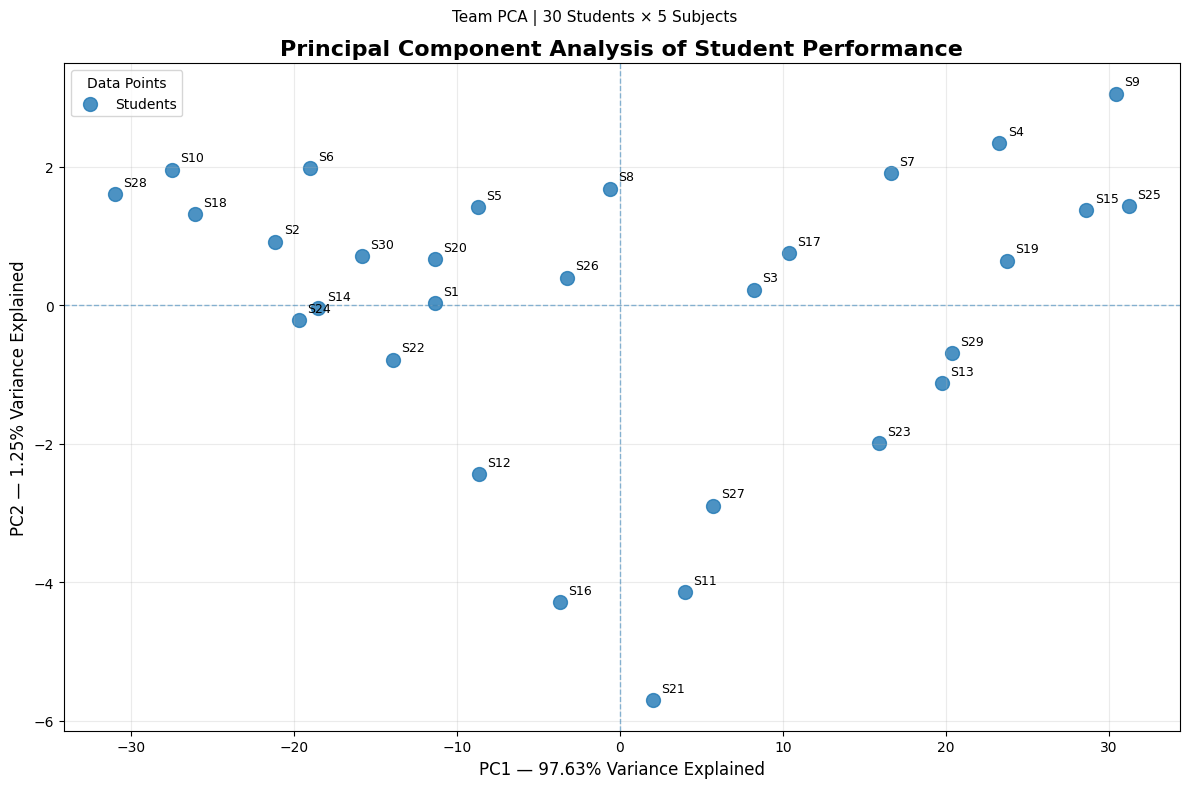

In [18]:
# ============================================================
# PCA 2D VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 8))

plt.scatter(
    Z[:, 0],
    Z[:, 1],
    s=100,
    alpha=0.8,
    label="Students"
)

# Label students
for i in range(n_students):

    plt.annotate(
        f"S{i + 1}",
        (Z[i, 0], Z[i, 1]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

# Reference axes
plt.axhline(
    0,
    linewidth=1,
    linestyle="--",
    alpha=0.5
)

plt.axvline(
    0,
    linewidth=1,
    linestyle="--",
    alpha=0.5
)

pc1_percent = (
    explained_variance_ratio[0] * 100
)

pc2_percent = (
    explained_variance_ratio[1] * 100
)

plt.xlabel(
    f"PC1 — {pc1_percent:.2f}% Variance Explained",
    fontsize=12
)

plt.ylabel(
    f"PC2 — {pc2_percent:.2f}% Variance Explained",
    fontsize=12
)

plt.title(
    "Principal Component Analysis of Student Performance",
    fontsize=16,
    fontweight="bold"
)

plt.suptitle(
    f"{TEAM_NAME} | 30 Students × 5 Subjects",
    fontsize=11
)

plt.legend(
    title="Data Points"
)

plt.grid(alpha=0.25)

plt.tight_layout()

plt.show()

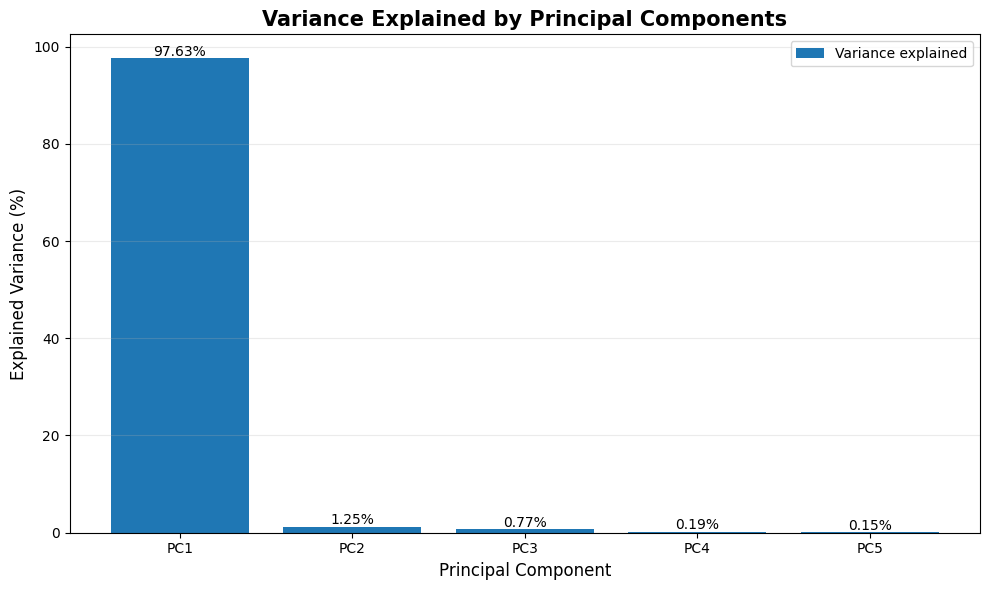

In [19]:
# ============================================================
# EXPLAINED VARIANCE BAR CHART
# ============================================================

pcs = [
    "PC1",
    "PC2",
    "PC3",
    "PC4",
    "PC5"
]

variance_percent = (
    explained_variance_ratio * 100
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    pcs,
    variance_percent,
    label="Variance explained"
)

plt.xlabel(
    "Principal Component",
    fontsize=12
)

plt.ylabel(
    "Explained Variance (%)",
    fontsize=12
)

plt.title(
    "Variance Explained by Principal Components",
    fontsize=15,
    fontweight="bold"
)

for bar, value in zip(
    bars,
    variance_percent
):

    plt.text(
        bar.get_x() +
        bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.legend()

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.show()

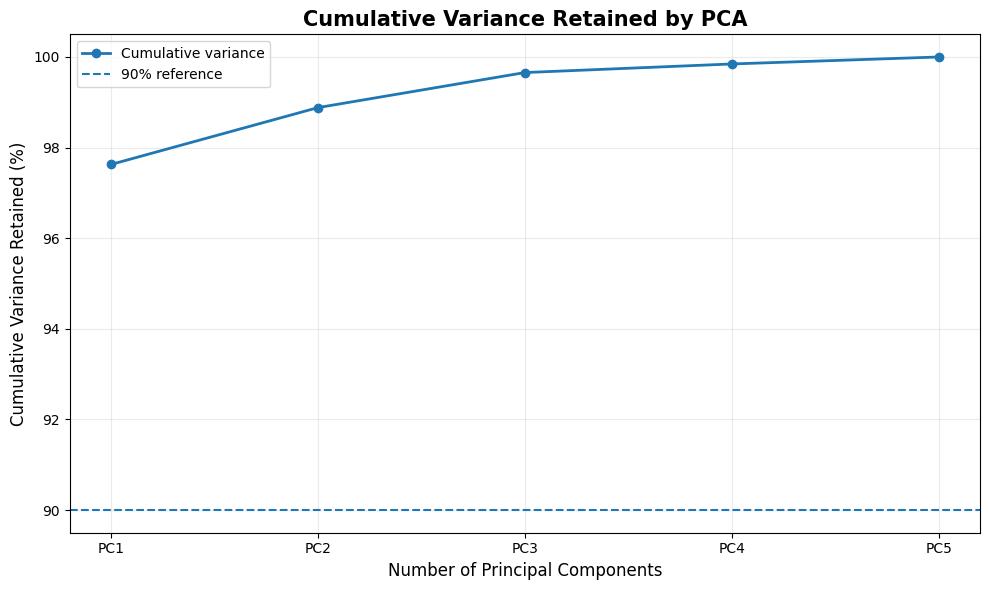

In [20]:
# ============================================================
# CUMULATIVE EXPLAINED VARIANCE
# ============================================================

cumulative_variance = (
    np.cumsum(
        explained_variance_ratio
    ) * 100
)

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, 6),
    cumulative_variance,
    marker="o",
    linewidth=2,
    label="Cumulative variance"
)

plt.axhline(
    90,
    linestyle="--",
    linewidth=1.5,
    label="90% reference"
)

plt.xticks(
    range(1, 6),
    pcs
)

plt.xlabel(
    "Number of Principal Components",
    fontsize=12
)

plt.ylabel(
    "Cumulative Variance Retained (%)",
    fontsize=12
)

plt.title(
    "Cumulative Variance Retained by PCA",
    fontsize=15,
    fontweight="bold"
)

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()

plt.show()

In [21]:
# ============================================================
# SUBJECT CONTRIBUTIONS TO PC1 AND PC2
# ============================================================

contribution_df = pd.DataFrame({
    "Subject": subjects,
    "PC1": W[:, 0],
    "PC2": W[:, 1]
})

print(
    "SUBJECT CONTRIBUTIONS "
    "TO PC1 AND PC2"
)

display(
    contribution_df.round(5)
)

SUBJECT CONTRIBUTIONS TO PC1 AND PC2


,Subject,PC1,PC2
0,Mathematics,-0.49315,0.09338
1,Physics,-0.39730,0.56722
2,Chemistry,-0.46734,0.25109
3,Programming,-0.43451,-0.76868
4,English,-0.43790,-0.12504


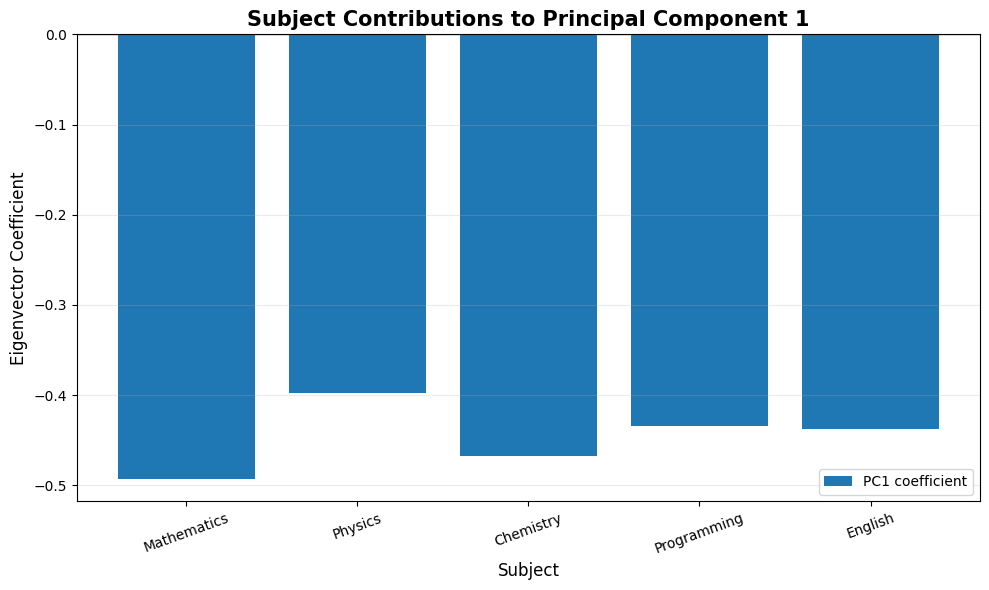

In [22]:
# ============================================================
# PC1 SUBJECT CONTRIBUTIONS
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    subjects,
    W[:, 0],
    label="PC1 coefficient"
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel(
    "Subject",
    fontsize=12
)

plt.ylabel(
    "Eigenvector Coefficient",
    fontsize=12
)

plt.title(
    "Subject Contributions to Principal Component 1",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(
    rotation=20
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.show()

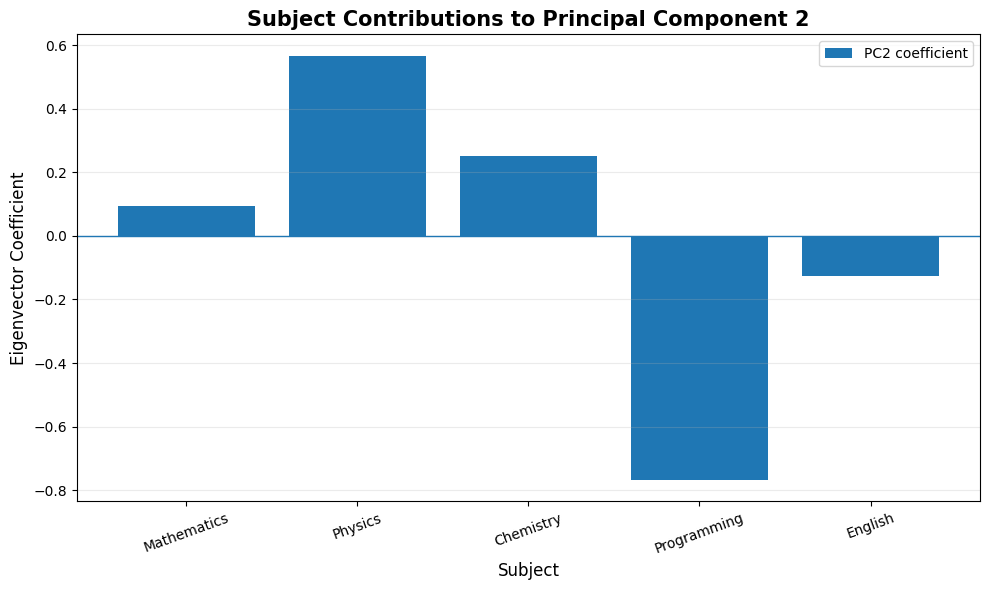

In [23]:
# ============================================================
# PC2 SUBJECT CONTRIBUTIONS
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    subjects,
    W[:, 1],
    label="PC2 coefficient"
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel(
    "Subject",
    fontsize=12
)

plt.ylabel(
    "Eigenvector Coefficient",
    fontsize=12
)

plt.title(
    "Subject Contributions to Principal Component 2",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(
    rotation=20
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.show()

In [24]:
# ============================================================
# STUDENT SIMILARITY ANALYSIS
# ============================================================

def find_similar_students(
    student_number,
    top_n=5
):

    index = student_number - 1

    selected_point = Z[index]

    # Euclidean distance in PCA space
    distances = np.linalg.norm(
        Z - selected_point,
        axis=1
    )

    sorted_indices = np.argsort(
        distances
    )

    results = []

    for idx in sorted_indices:

        # Skip the selected student
        if idx == index:
            continue

        results.append({
            "Student":
                student_names[idx],

            "PC1":
                Z[idx, 0],

            "PC2":
                Z[idx, 1],

            "PCA Distance":
                distances[idx]
        })

        if len(results) == top_n:
            break

    return pd.DataFrame(results)


# Change this number to analyze another student
selected_student = 1

similar_students = find_similar_students(
    selected_student,
    top_n=5
)

print(
    f"Students most similar to "
    f"Student {selected_student}:"
)

display(
    similar_students.round(4)
)

Students most similar to Student 1:


,Student,PC1,PC2,PCA Distance
0,Student 20,-11.3615,0.6674,0.6433
1,Student 22,-13.9234,-0.7870,2.7081
2,Student 5,-8.6968,1.4181,2.9878
3,Student 12,-8.6392,-2.4433,3.6582
4,Student 30,-15.8219,0.7033,4.5333


In [25]:
# ============================================================
# MATHEMATICAL VERIFICATION
# ============================================================

print("VERIFYING Cv = λv")
print()

for i in range(5):

    v = eigenvectors_sorted[:, i]

    lam = eigenvalues_sorted[i]

    left_side = (
        covariance_matrix @ v
    )

    right_side = (
        lam * v
    )

    error = np.linalg.norm(
        left_side - right_side
    )

    print(
        f"Eigenvector {i + 1}: "
        f"λ = {lam:.6f}, "
        f"error = {error:.10f}"
    )

print(
    "\nVery small errors confirm "
    "the eigenvalue/eigenvector solution."
)

VERIFYING Cv = λv

Eigenvector 1: λ = 351.640782, error = 0.0000000000
Eigenvector 2: λ = 4.517984, error = 0.0000000000
Eigenvector 3: λ = 2.786191, error = 0.0000000000
Eigenvector 4: λ = 0.682752, error = 0.0000000000
Eigenvector 5: λ = 0.555050, error = 0.0000000000

Very small errors confirm the eigenvalue/eigenvector solution.


In [26]:
# ============================================================
# FINAL PROJECT SUMMARY
# ============================================================

print("=" * 75)
print(
    "        PRINCIPAL COMPONENT ANALYSIS - FINAL RESULT"
)
print("=" * 75)

print(f"\nTeam       : {TEAM_NAME}")
print(f"Domain     : {PROJECT_DOMAIN}")
print(f"Students   : {n_students}")
print(f"Subjects   : {len(subjects)}")

print("\nSubjects:")

for subject in subjects:
    print(f"  • {subject}")

print("\n" + "-" * 75)

print("EIGENVALUES AND EXPLAINED VARIANCE")

print("-" * 75)

for i in range(5):

    print(
        f"PC{i + 1}: "
        f"Eigenvalue = "
        f"{eigenvalues_sorted[i]:.4f} | "
        f"Variance = "
        f"{explained_variance_ratio[i] * 100:.2f}%"
    )

print("\n" + "-" * 75)

print("TOP 2 PRINCIPAL COMPONENTS")

print("-" * 75)

print(
    f"PC1 variance : "
    f"{explained_variance_ratio[0] * 100:.2f}%"
)

print(
    f"PC2 variance : "
    f"{explained_variance_ratio[1] * 100:.2f}%"
)

print(
    f"PC1 + PC2    : "
    f"{top2_variance:.2f}%"
)

print("\n" + "-" * 75)

print("MATHEMATICAL PIPELINE")

print("-" * 75)

print("1. Center data       : Xc = X - μ")
print("2. Covariance matrix : C = Xcᵀ Xc / (n - 1)")
print("3. Eigen problem     : Cv = λv")
print("4. Select top 2      : W = [v₁  v₂]")
print("5. Project to 2D     : Z = XcW")

print("\n" + "=" * 75)

print(
    "             PCA PROJECT COMPLETED SUCCESSFULLY"
)

print("=" * 75)

        PRINCIPAL COMPONENT ANALYSIS - FINAL RESULT

Team       : Team PCA
Domain     : Data Science / Machine Learning / Analytics
Students   : 30
Subjects   : 5

Subjects:
  • Mathematics
  • Physics
  • Chemistry
  • Programming
  • English

---------------------------------------------------------------------------
EIGENVALUES AND EXPLAINED VARIANCE
---------------------------------------------------------------------------
PC1: Eigenvalue = 351.6408 | Variance = 97.63%
PC2: Eigenvalue = 4.5180 | Variance = 1.25%
PC3: Eigenvalue = 2.7862 | Variance = 0.77%
PC4: Eigenvalue = 0.6828 | Variance = 0.19%
PC5: Eigenvalue = 0.5550 | Variance = 0.15%

---------------------------------------------------------------------------
TOP 2 PRINCIPAL COMPONENTS
---------------------------------------------------------------------------
PC1 variance : 97.63%
PC2 variance : 1.25%
PC1 + PC2    : 98.88%

---------------------------------------------------------------------------
MATHEMATICAL PIPELINE
-

PCA SENSITIVITY ANALYSIS

Question:
How much information is retained when different numbers of principal components are used?


1 Principal Component(s): 97.63% variance retained
2 Principal Component(s): 98.88% variance retained
3 Principal Component(s): 99.66% variance retained
4 Principal Component(s): 99.85% variance retained
5 Principal Component(s): 100.00% variance retained

----------------------------------------------------------------------
Minimum PCs required to retain at least 90% variance: 1
----------------------------------------------------------------------


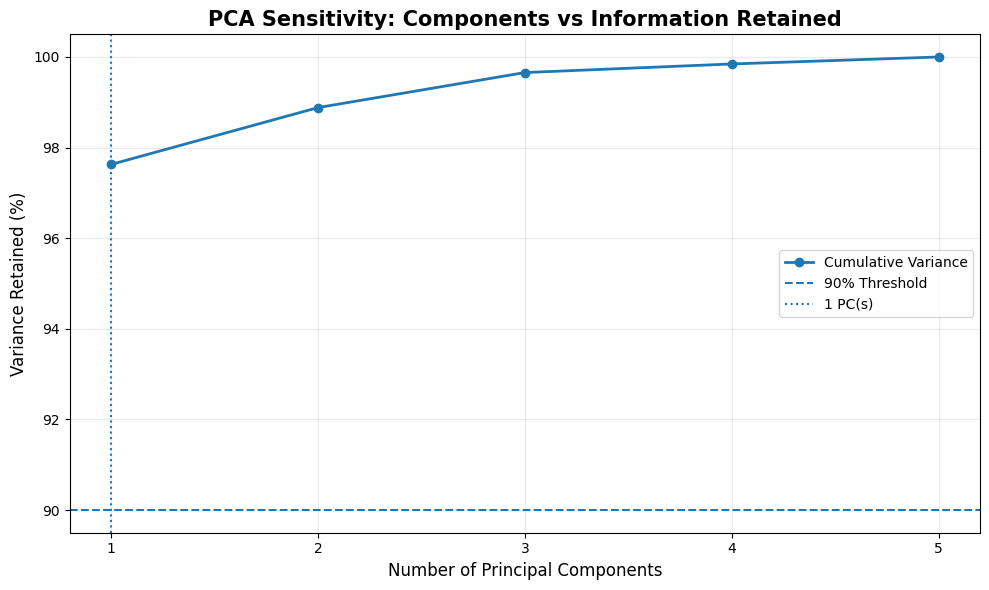

In [27]:
# ============================================================
# ADDITIONAL ANALYSIS
# PCA DIMENSIONALITY REDUCTION SENSITIVITY
# ============================================================

print("=" * 70)
print("PCA SENSITIVITY ANALYSIS")
print("=" * 70)

print(
    "\nQuestion:"
)

print(
    "How much information is retained when "
    "different numbers of principal components are used?"
)

print("\n")

for i, value in enumerate(
    cumulative_variance,
    start=1
):

    print(
        f"{i} Principal Component(s): "
        f"{value:.2f}% variance retained"
    )

# Find components required for 90% variance
components_90 = (
    np.argmax(
        cumulative_variance >= 90
    ) + 1
)

print("\n" + "-" * 70)

print(
    f"Minimum PCs required to retain "
    f"at least 90% variance: {components_90}"
)

print("-" * 70)


# ============================================================
# SENSITIVITY PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, 6),
    cumulative_variance,
    marker="o",
    linewidth=2,
    label="Cumulative Variance"
)

plt.axhline(
    90,
    linestyle="--",
    linewidth=1.5,
    label="90% Threshold"
)

plt.axvline(
    components_90,
    linestyle=":",
    linewidth=1.5,
    label=f"{components_90} PC(s)"
)

plt.xticks(
    range(1, 6)
)

plt.xlabel(
    "Number of Principal Components",
    fontsize=12
)

plt.ylabel(
    "Variance Retained (%)",
    fontsize=12
)

plt.title(
    "PCA Sensitivity: Components vs Information Retained",
    fontsize=15,
    fontweight="bold"
)

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()

plt.show()

In [28]:
# ============================================================
# AUTOMATIC INTERPRETATION
# ============================================================

print("=" * 70)
print("PCA INTERPRETATION")
print("=" * 70)

print(
    f"\nPC1 captures "
    f"{explained_variance_ratio[0] * 100:.2f}% "
    f"of the total variation in student marks."
)

print(
    f"PC2 captures "
    f"{explained_variance_ratio[1] * 100:.2f}% "
    f"of the total variation."
)

print(
    f"\nTogether, PC1 and PC2 retain "
    f"{top2_variance:.2f}% "
    f"of the original information."
)

print(
    "\nThe PCA scatter plot represents each student "
    "using only two coordinates instead of five subject marks."
)

print(
    "\nStudents located close together in the PCA plot "
    "have similar patterns across the five subjects."
)

print(
    "\nThe eigenvectors determine the principal directions, "
    "while the eigenvalues determine how much variance "
    "is associated with those directions."
)

print(
    "\nThis demonstrates how PCA can reduce dimensionality "
    "while preserving the most important variation in data."
)

print("\n" + "=" * 70)
print("END OF PROJECT")
print("=" * 70)

PCA INTERPRETATION

PC1 captures 97.63% of the total variation in student marks.
PC2 captures 1.25% of the total variation.

Together, PC1 and PC2 retain 98.88% of the original information.

The PCA scatter plot represents each student using only two coordinates instead of five subject marks.

Students located close together in the PCA plot have similar patterns across the five subjects.

The eigenvectors determine the principal directions, while the eigenvalues determine how much variance is associated with those directions.

This demonstrates how PCA can reduce dimensionality while preserving the most important variation in data.

END OF PROJECT
